   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 11.1 MB/s eta 0:00:00
Starting Complete NLP Project System...


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Loaded 2611 rows from: fake_or_real_news.csv
label  label_num
FAKE   0            1331
REAL   1            1280
Name: count, dtype: int64

Preprocessing...

PART 1: FAKE NEWS CLASSIFICATION
Accuracy: 89.10%

Classification Report:
              precision    recall  f1-score   support

        Fake       0.88      0.92      0.90       267
        Real       0.91      0.86      0.89       256

    accuracy                           0.89       523
   macro avg       0.89      0.89      0.89       523
weighted avg       0.89      0.89      0.89       523



,Pred Fake,Pred Real
Actual Fake,245,22
Actual Real,35,221


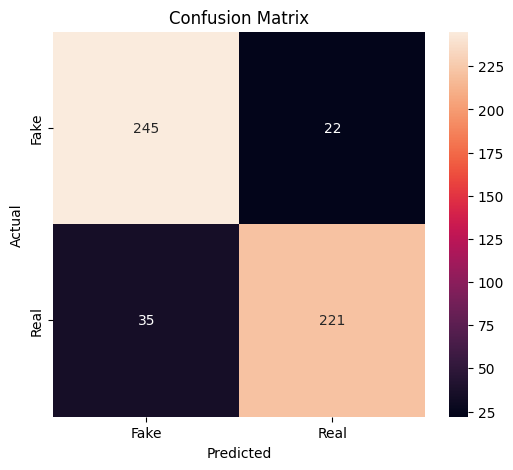


PART 2: VECTOR SPACE ANALYSIS (First 5 Docs Sample)

1) Term–Document Matrix:


,abc,abcpolitics,abedin,aboutface,abroad,abuse,according,account,accused,accusing
Doc1,0,0,1,0,0,1,0,0,1,2
Doc2,1,1,0,1,0,0,0,0,0,0
Doc3,0,0,0,0,1,0,0,0,0,0
Doc4,0,0,0,0,0,0,1,1,0,0
Doc5,0,0,0,0,0,0,0,0,0,0



2) Word–Word Co-occurrence Matrix (Window=2):


,greenfield,shillman,daniel,journalism,fellow,freedom,center,new,york,writer
daniel,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
shillman,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
journalism,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
greenfield,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
fellow,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
freedom,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0
center,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0
new,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,8.0,1.0
york,0.0,0.0,0.0,0.0,0.0,0.0,1.0,8.0,0.0,1.0
writer,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0



3) TF–IDF Matrix (sample):


,abc,abcpolitics,abedin,aboutface,abroad,abuse,according,account,accused,accusing
Doc1,0.000000,0.000000,0.020576,0.000000,0.000000,0.020576,0.000000,0.000000,0.020576,0.041151
Doc2,0.058338,0.058338,0.000000,0.058338,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Doc3,0.000000,0.000000,0.000000,0.000000,0.047137,0.000000,0.000000,0.000000,0.000000,0.000000
Doc4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.054288,0.054288,0.000000,0.000000
Doc5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



4) Cosine Similarity:


,Doc1,Doc2,Doc3,Doc4,Doc5
Doc1,1.000000,0.063938,0.024692,0.195256,0.118662
Doc2,0.063938,1.000000,0.056962,0.096873,0.107263
Doc3,0.024692,0.056962,1.000000,0.027663,0.051016
Doc4,0.195256,0.096873,0.027663,1.000000,0.238793
Doc5,0.118662,0.107263,0.051016,0.238793,1.000000


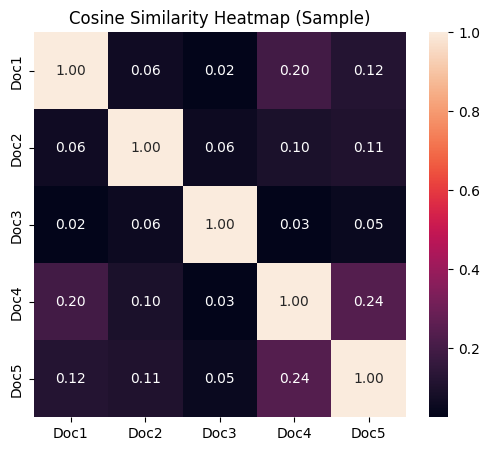


Saving Matrices to Excel...
Excel file 'Project_Vector_Models.xlsx' created successfully!

PART 4: WORD2VEC EMBEDDINGS + PCA VISUALIZATION


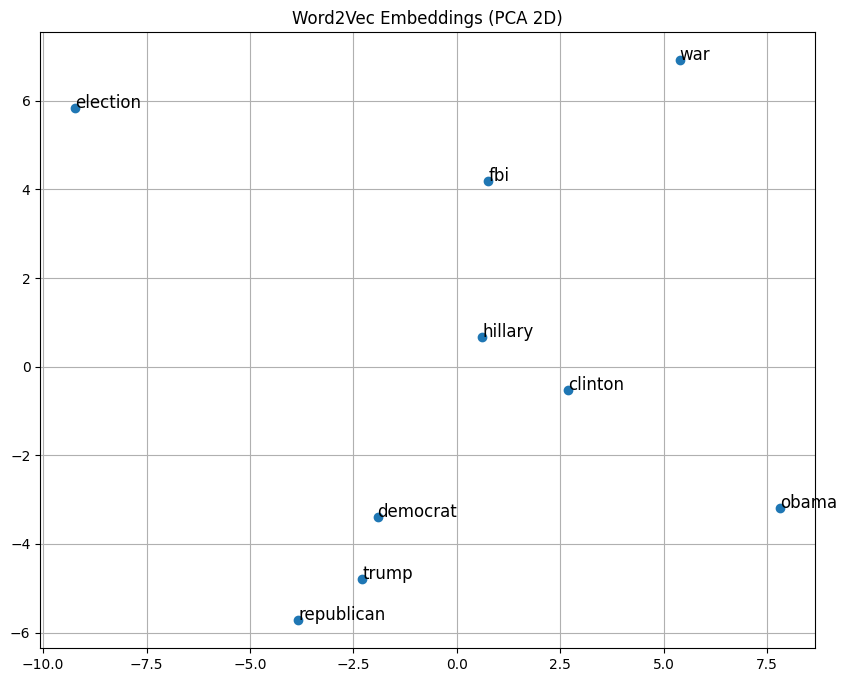


DONE ✅


In [1]:
# ======================================================
# COMPLETE NLP PROJECT: Fake News Detection + VSM + Word2Vec
# Fixed: No Data Leakage + Stratified Split + Full Evaluation
# ======================================================

# --- 1) INSTALLATION (Colab) ---
# If you're in Jupyter locally and packages already installed, you can comment this out.
!pip -q install gensim xlsxwriter

# --- 2) IMPORTS ---
import os
import re
import numpy as np
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter, defaultdict
from IPython.display import display

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

from gensim.models import Word2Vec

print("Starting Complete NLP Project System...")

# --- 3) NLTK DOWNLOADS ---
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

# --- 4) LOAD DATA ---
# Prefer the uploaded file path if available
CSV_PATH = "/mnt/data/fake_or_real_news.csv"
FALLBACK_URL = "https://raw.githubusercontent.com/NathanielRin/Fake-News-Detection/master/fake_or_real_news.csv"

if not os.path.exists(CSV_PATH):
    # fallback to local filename and download if needed
    CSV_PATH = "fake_or_real_news.csv"
    if not os.path.exists(CSV_PATH):
        print(f"Downloading '{CSV_PATH}' from GitHub...")
        !wget -q {FALLBACK_URL} -O {CSV_PATH}
        print("Downloaded successfully.")

try:
    data = pd.read_csv(CSV_PATH, engine="python", on_bad_lines="skip")
    data.columns = data.columns.str.strip().str.lower()

    # Map labels to numbers
    data["label_num"] = data["label"].map({"fake": 0, "real": 1, "FAKE": 0, "REAL": 1})

    # Basic cleaning
    data = data.dropna(subset=["text", "label_num"]).copy()
    data["label_num"] = data["label_num"].astype(int)

    X_raw = data["text"].astype(str)
    y = data["label_num"]

    print(f"Loaded {len(data)} rows from: {CSV_PATH}")
    print(data[["label", "label_num"]].value_counts().head())

except Exception as e:
    print(f"Error loading data: {e}")
    raise

# --- 5) PREPROCESSING ---
print("\nPreprocessing...")
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text: str):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)  # keep letters/spaces only
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 1]
    return " ".join(tokens), tokens

results = [preprocess_text(doc) for doc in X_raw]
X_processed = [r[0] for r in results]
tokenized_corpus = [r[1] for r in results]

# ======================================================
# PART 1: CLASSIFICATION (No Leakage + Stratify)
# ======================================================
print("\n" + "="*60)
print("PART 1: FAKE NEWS CLASSIFICATION")
print("="*60)

# Split FIRST (important) + stratify to keep label balance
X_train, X_test, y_train, y_test = train_test_split(
    pd.Series(X_processed),
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Vectorizer: Fit ONLY on train (important)
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# Predict + evaluate
y_pred = model.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2%}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Fake", "Real"]))

# Confusion matrix table
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=["Actual Fake", "Actual Real"], columns=["Pred Fake", "Pred Real"])
display(cm_df)

# Confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Fake","Real"], yticklabels=["Fake","Real"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ======================================================
# PART 2: VECTOR SPACE MODELS (Sample for readability)
# ======================================================
print("\n" + "="*60)
print("PART 2: VECTOR SPACE ANALYSIS (First 5 Docs Sample)")
print("="*60)

sample_size = 5
sample_corpus = X_processed[:sample_size]
doc_names = [f"Doc{i+1}" for i in range(sample_size)]

# 1) Term–Document Matrix
print("\n1) Term–Document Matrix:")
count_vect = CountVectorizer()
td_matrix = count_vect.fit_transform(sample_corpus).toarray()
td_df = pd.DataFrame(td_matrix, columns=count_vect.get_feature_names_out(), index=doc_names)
display(td_df.iloc[:, :10])  # first 10 columns for readability

# 2) Word–Word Co-occurrence Matrix (window=2)
print("\n2) Word–Word Co-occurrence Matrix (Window=2):")
window_size = 2
co_occurrence = defaultdict(Counter)

for doc in sample_corpus:
    words = doc.split()
    for i, word in enumerate(words):
        start = max(0, i - window_size)
        end = min(len(words), i + window_size + 1)
        for j in range(start, end):
            if i != j:
                co_occurrence[word][words[j]] += 1

ww_matrix = pd.DataFrame.from_dict(co_occurrence, orient="index").fillna(0)
display(ww_matrix.iloc[:10, :10])

# 3) TF–IDF Matrix (sample)
print("\n3) TF–IDF Matrix (sample):")
tfidf_sample = TfidfVectorizer()
tfidf_mat_sample = tfidf_sample.fit_transform(sample_corpus).toarray()
tfidf_df = pd.DataFrame(tfidf_mat_sample, columns=tfidf_sample.get_feature_names_out(), index=doc_names)
display(tfidf_df.iloc[:, :10])

# 4) Cosine Similarity
print("\n4) Cosine Similarity:")
sim_matrix = cosine_similarity(tfidf_mat_sample)
sim_df = pd.DataFrame(sim_matrix, columns=doc_names, index=doc_names)
display(sim_df)

plt.figure(figsize=(6, 5))
sns.heatmap(sim_df, annot=True, fmt=".2f")
plt.title("Cosine Similarity Heatmap (Sample)")
plt.show()

# ======================================================
# PART 3: SAVE MATRICES TO EXCEL
# ======================================================
print("\nSaving Matrices to Excel...")
excel_name = "Project_Vector_Models.xlsx"

with pd.ExcelWriter(excel_name) as writer:
    td_df.to_excel(writer, sheet_name="Term_Doc_Matrix")
    ww_matrix.to_excel(writer, sheet_name="Word_Word_Matrix")
    tfidf_df.to_excel(writer, sheet_name="TF_IDF_Sample")
    sim_df.to_excel(writer, sheet_name="Cosine_Similarity_Sample")

print(f"Excel file '{excel_name}' created successfully!")

# ======================================================
# PART 4: WORD EMBEDDINGS (Word2Vec) + PCA PLOT
# ======================================================
print("\n" + "="*60)
print("PART 4: WORD2VEC EMBEDDINGS + PCA VISUALIZATION")
print("="*60)

# To reduce time, train on a subset (optional). Comment out if you want full corpus.
MAX_W2V_DOCS = 8000
token_sample = tokenized_corpus[:MAX_W2V_DOCS]

w2v_model = Word2Vec(
    sentences=token_sample,
    vector_size=50,     # reduced for speed
    window=5,
    min_count=5,
    workers=4
)

words_to_plot = [
    "hillary", "trump", "obama", "clinton",
    "republican", "democrat", "fbi", "election", "war"
]
words_to_plot = [w for w in words_to_plot if w in w2v_model.wv]

if len(words_to_plot) < 2:
    print("Not enough target words found in vocabulary to plot PCA.")
else:
    word_vectors = np.array([w2v_model.wv[w] for w in words_to_plot])
    pca = PCA(n_components=2)
    result = pca.fit_transform(word_vectors)

    plt.figure(figsize=(10, 8))
    plt.scatter(result[:, 0], result[:, 1])
    for i, word in enumerate(words_to_plot):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]), fontsize=12)
    plt.title("Word2Vec Embeddings (PCA 2D)")
    plt.grid(True)
    plt.show()

print("\nDONE ✅")
